# Result Analysis

This notebook loads the append-only CSV outputs from `results/attack_results/` and `results/algorithm_results/` and summarizes attack reconstruction quality and model performance.

In [1]:
from analysis_utils import (
    load_attack_results,
    load_algorithm_results,
    attack_summary,
    algorithm_summary,
    plot_attack_metric,
    plot_attack_metric_by_round,
    plot_algorithm_crossentropy,
    plot_algorithm_accuracy,
)

attack_rows = load_attack_results()
algorithm_rows = load_algorithm_results()

attack_rows[:3] if isinstance(attack_rows, list) else attack_rows.head(), algorithm_rows[:3] if isinstance(algorithm_rows, list) else algorithm_rows.head()

([{'index': '0',
   'run': '0',
   'communication_round': '1',
   'client_id': '0',
   'sample_index': '0',
   'algorithm': 'FedAvg',
   'attack': 'DLG',
   'real input value': '[[[0.1882352977991104, 0.2078431397676468, 0.47843137383461], [0.18039216101169586, 0.20392157137393951, 0.46666666865348816], [0.1764705926179886, 0.20392157137393951, 0.47058823704719543], [0.1764705926179886, 0.20392157137393951, 0.47058823704719543], [0.1764705926179886, 0.20392157137393951, 0.47058823704719543], [0.18039216101169586, 0.20392157137393951, 0.47058823704719543], [0.18431372940540314, 0.20000000298023224, 0.47058823704719543], [0.18431372940540314, 0.20000000298023224, 0.47058823704719543], [0.18431372940540314, 0.20000000298023224, 0.47058823704719543], [0.18431372940540314, 0.20000000298023224, 0.47058823704719543], [0.18431372940540314, 0.20000000298023224, 0.47058823704719543], [0.18431372940540314, 0.20000000298023224, 0.47058823704719543], [0.18431372940540314, 0.20000000298023224, 0.458

## Summary Tables

In [2]:
attack_summary(attack_rows)

[{'algorithm': 'FedAvg',
  'attack': 'DLG',
  'rows': 4,
  'mean_mse': 0.033291228814050555,
  'min_mse': 0.009098297916352749,
  'max_mse': 0.10256236791610718,
  'mean_psnr': 17.424461126327515,
  'min_psnr': 9.890118598937988,
  'max_psnr': 20.410398483276367,
  'mean_ssim': 0.5320475306361914,
  'min_ssim': 0.07150693982839584,
  'max_ssim': 0.7443622946739197},
 {'algorithm': 'FedAvg',
  'attack': 'InvertingGradients',
  'rows': 4,
  'mean_mse': 0.0038455687754321843,
  'min_mse': 0.0017751673003658652,
  'max_mse': 0.00514428922906518,
  'mean_psnr': 24.474425792694092,
  'min_psnr': 22.886743545532227,
  'max_psnr': 27.507604598999023,
  'mean_ssim': 0.7848679274320602,
  'min_ssim': 0.6918209195137024,
  'max_ssim': 0.8468177914619446},
 {'algorithm': 'FedPer(K_p=1)',
  'attack': 'DLG',
  'rows': 4,
  'mean_mse': 0.045747671043500304,
  'min_mse': 0.008685181848704815,
  'max_mse': 0.10256189107894897,
  'mean_psnr': 15.47996211051941,
  'min_psnr': 9.89013957977295,
  'max_psn

In [3]:
algorithm_summary(algorithm_rows)

[{'algorithm': 'FedAvg',
  'rows': 8,
  'mean_crossentropy': 0.9219957590103149,
  'min_crossentropy': 0.8510677814483643,
  'max_crossentropy': 0.9929497838020325,
  'accuracy': 0.5},
 {'algorithm': 'FedPer(K_p=1)',
  'rows': 8,
  'mean_crossentropy': 0.10384355299174786,
  'min_crossentropy': 0.09297096729278564,
  'max_crossentropy': 0.11470875144004822,
  'accuracy': 1.0},
 {'algorithm': 'FedPer(K_p=2)',
  'rows': 8,
  'mean_crossentropy': 0.08787153102457523,
  'min_crossentropy': 0.0751459077000618,
  'max_crossentropy': 0.10059139877557755,
  'accuracy': 1.0},
 {'algorithm': 'FedPer(K_p=3)',
  'rows': 8,
  'mean_crossentropy': 0.08732998371124268,
  'min_crossentropy': 0.07452613860368729,
  'max_crossentropy': 0.1001281812787056,
  'accuracy': 1.0},
 {'algorithm': 'FedPer(K_p=4)',
  'rows': 8,
  'mean_crossentropy': 0.08725515939295292,
  'min_crossentropy': 0.07444281876087189,
  'max_crossentropy': 0.10006173700094223,
  'accuracy': 1.0},
 {'algorithm': 'FedPer(K_p=5)',
  'ro

## Attack Comparisons

<Axes: title={'center': 'Mean input mse by algorithm and attack'}, xlabel='Algorithm', ylabel='input mse'>

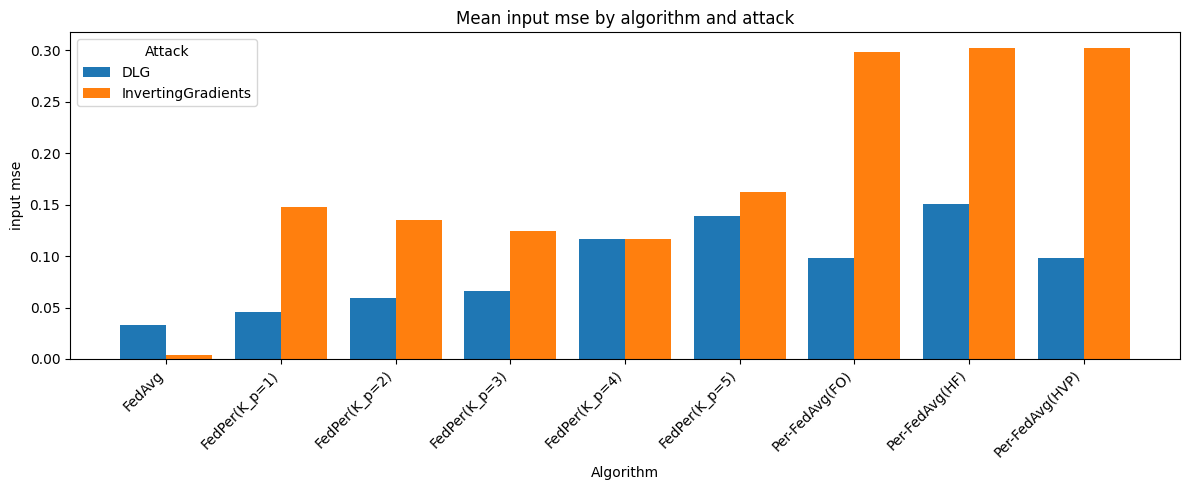

In [5]:
plot_attack_metric(attack_rows, "input mse")

<Axes: title={'center': 'Mean input psnr by algorithm and attack'}, xlabel='Algorithm', ylabel='input psnr'>

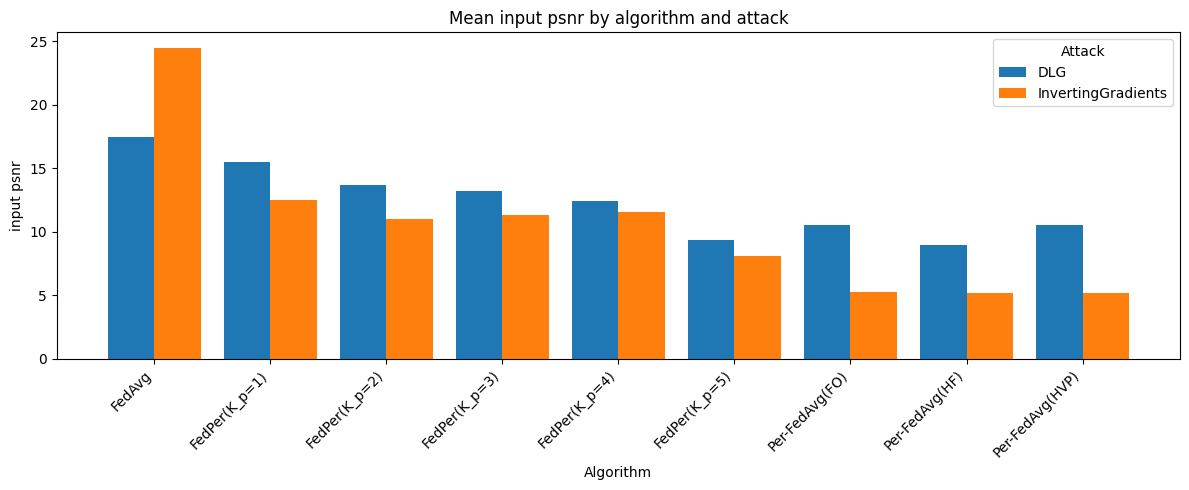

In [6]:
plot_attack_metric(attack_rows, "input psnr")

<Axes: title={'center': 'Mean input ssim by algorithm and attack'}, xlabel='Algorithm', ylabel='input ssim'>

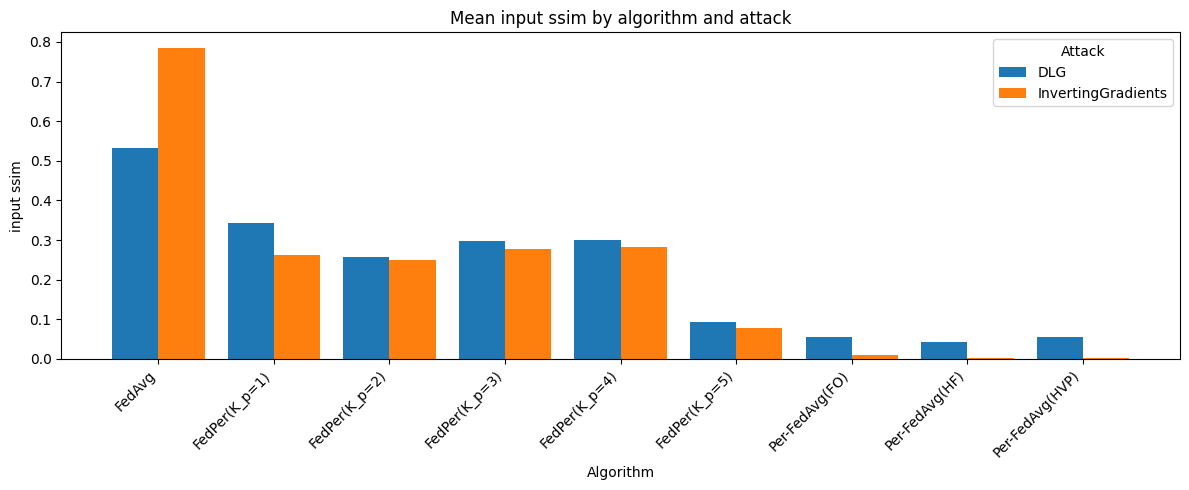

In [7]:
plot_attack_metric(attack_rows, "input ssim")

<Axes: title={'center': 'Mean input mse by communication round'}, xlabel='Communication round', ylabel='input mse'>

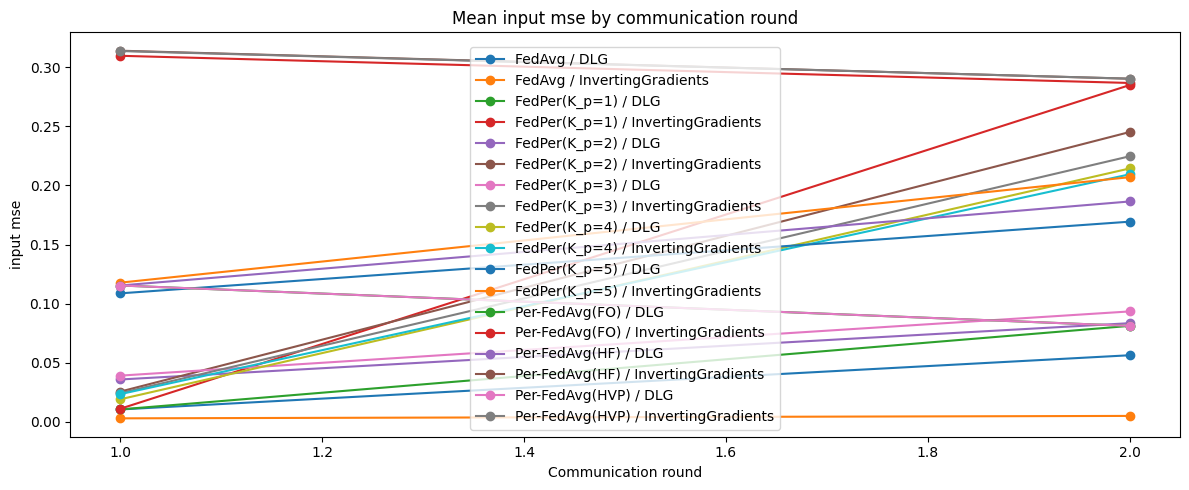

In [8]:
plot_attack_metric_by_round(attack_rows, "input mse")

## Model Performance

<Axes: title={'center': 'Mean output crossentropy by algorithm'}, xlabel='Algorithm', ylabel='Output crossentropy'>

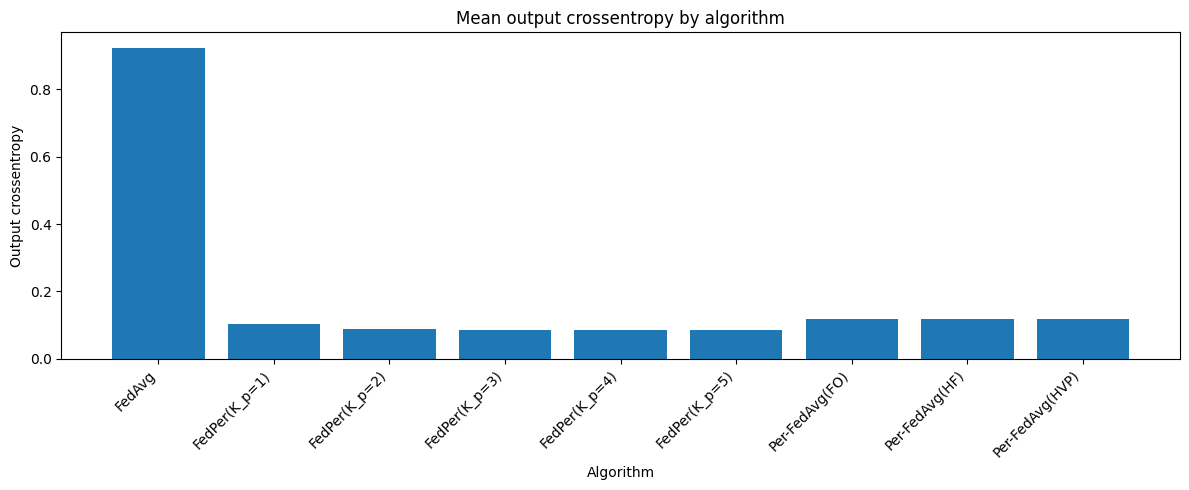

In [9]:
plot_algorithm_crossentropy(algorithm_rows)

<Axes: title={'center': 'Prediction accuracy by algorithm'}, xlabel='Algorithm', ylabel='Accuracy'>

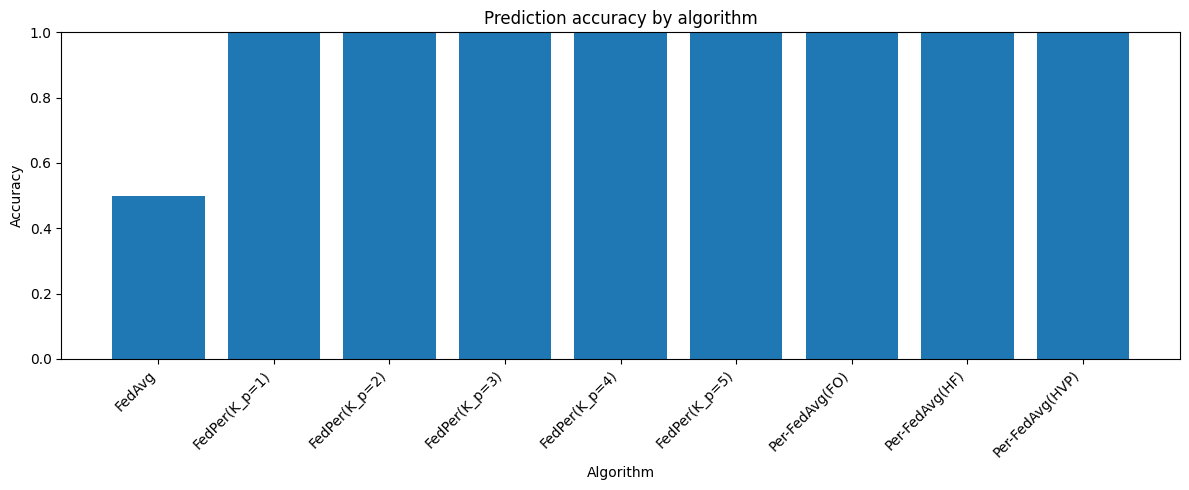

In [10]:
plot_algorithm_accuracy(algorithm_rows)